# Project Introduction

# Customer Segmentation Analysis using RFM and K-Means

## Oasis Infobyte – Data Analytics Internship

### Objective

The objective of this project is to segment customers based on their purchasing behaviour using RFM analysis and K-Means clustering.

RFM represents:

- Recency – How recently a customer made a purchase
- Frequency – How frequently a customer makes purchases
- Monetary – How much a customer spends

The resulting customer segments can be used to support targeted marketing strategies.

# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


## Load the Online Retail Dataset

In [2]:
import kagglehub
path = kagglehub.dataset_download("cgrymn/online-retail-ii-uci-dataset")

100%|██████████| 43.3M/43.3M [00:00<00:00, 116MB/s]

Extracting files...


In [3]:
import os

print("Dataset path:")
print(path)

print("\nFiles in dataset:")
print(os.listdir(path))

Dataset path:
/root/.cache/kagglehub/datasets/cgrymn/online-retail-ii-uci-dataset/versions/1

Files in dataset:
['online_retail_II.xlsx']


In [4]:
file_path= os.path.join(path, "online_retail_II.xlsx")
df= pd.read_excel(file_path)
print("Data loaded successfully!")

Data loaded successfully!


In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Inspect the dataset

In [6]:
# Number of rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 525461
Columns: 8


In [7]:
# Column names
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [8]:
# Data types
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object


In [9]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [10]:
# Missing Values
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [11]:
# Duplicate records
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 6865


# Data Cleaning

In [12]:
# Remove missing Customer IDs
df.dropna(subset=['Customer ID'], inplace=True)

In [13]:
# Convert Customer ID
df['Customer ID']= df['Customer ID'].astype(int)

In [14]:
# Convert date
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])

In [15]:
# Remove invalid quantities
df= df[df['Quantity'] > 0]

In [16]:
# Remove invalid prices
df = df[df['Price'] > 0]

In [17]:
# Check result
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (407664, 8)


# Create Total Purchase Amount

In [18]:
df['TotalAmount']= df['Quantity'] * df['Price']

In [19]:
df[['Quantity', 'Price', 'TotalAmount']].head()

,Quantity,Price,TotalAmount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


# RFM Analysis

In [20]:
reference_date= df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference Data:", reference_date)

Reference Data: 2010-12-10 20:01:00


In [21]:
# Now calculate RFM:
rfm= df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum'

})

In [22]:
rfm.columns= ['Recency', 'Frequency', 'Monetary']

In [23]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,165,11,372.86
12347,3,2,1323.32
12348,74,1,222.16
12349,43,3,2671.14
12351,11,1,300.93


# Descriptive Statistics
The task specifically asks for average purchase value, purchase frequency and customer lifetime value.

In [24]:
rfm.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2048.238236
std,96.860633,8.170213,8914.481280
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.987500
50%,53.000000,2.000000,706.020000
75%,136.000000,5.000000,1723.142500
max,374.000000,205.000000,349164.350000


In [25]:
# Average purchase value
average_purchase_value= df['TotalAmount'].mean()
print("Average Purchase Value:", round(average_purchase_value, 2))

Average Purchase Value: 21.66


In [26]:
# Average purchase frequency
average_purchase_frequency= rfm['Frequency'].mean()
print("Average Purchase Frequency:", round(average_purchase_frequency, 2))

Average Purchase Frequency: 4.46


In [27]:
average_customer_value = rfm['Monetary'].mean()

print("Average Historical Customer Value:", round(average_customer_value, 2))

Average Historical Customer Value: 2048.24


# Standardise RFM
K-Means is sensitive to feature scale, so standardisation is required.

In [28]:
rfm_features= rfm[['Recency', 'Frequency', 'Monetary']]

# Apply StandardScaler
Data normalisation/standardisation before clustering using StandardScaler.

In [29]:
scaler= StandardScaler()

rfm_scaled= scaler.fit_transform(rfm_features)

rfm_scaled= pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index= rfm.index
    )
rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,0.762299,0.801087,-0.187961
12347,-0.910402,-0.300603,-0.081329
12348,-0.177305,-0.423013,-0.204868
12349,-0.497389,-0.178193,0.069883
12351,-0.827799,-0.423013,-0.196031


# Elbow Method
This determines an appropriate number of clusters.

In [30]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

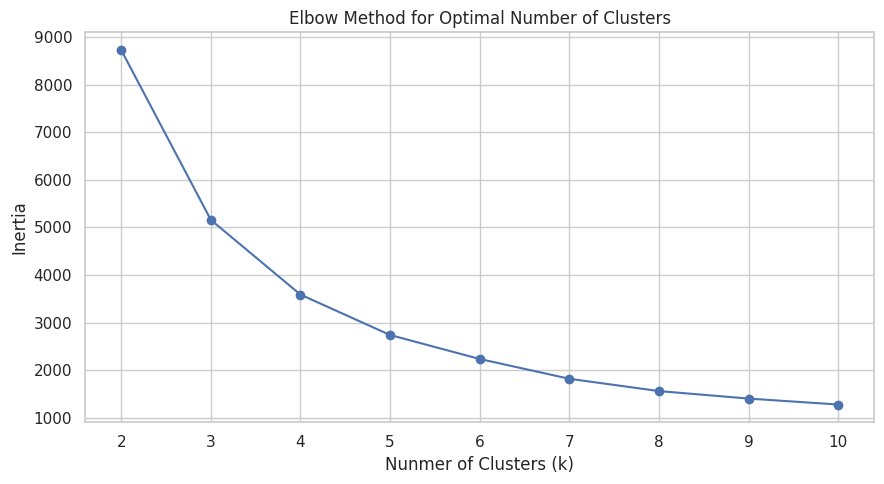

In [31]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Nunmer of Clusters (k)')
plt.ylabel('Inertia')

plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

Look at your actual graph and identify where the reduction in inertia starts becoming less significant.

If the elbow appears around K = 4

In [32]:
optimal_k = 4

# Apply K-Means

In [33]:
# K-Means clustering with K = 4

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed successfully!")

K-Means clustering completed successfully!


In [34]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346,165,11,372.86,1
12347,3,2,1323.32,0
12348,74,1,222.16,0
12349,43,3,2671.14,0
12351,11,1,300.93,0


# Cluster Visualisation

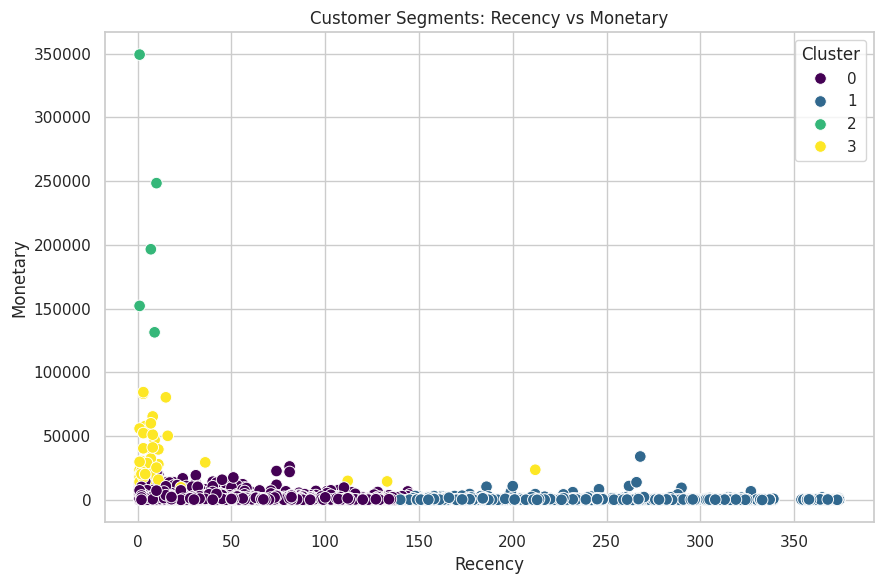

In [35]:
# Recency vs Monetary
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=70
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency')
plt.ylabel('Monetary')

plt.tight_layout()
plt.show()

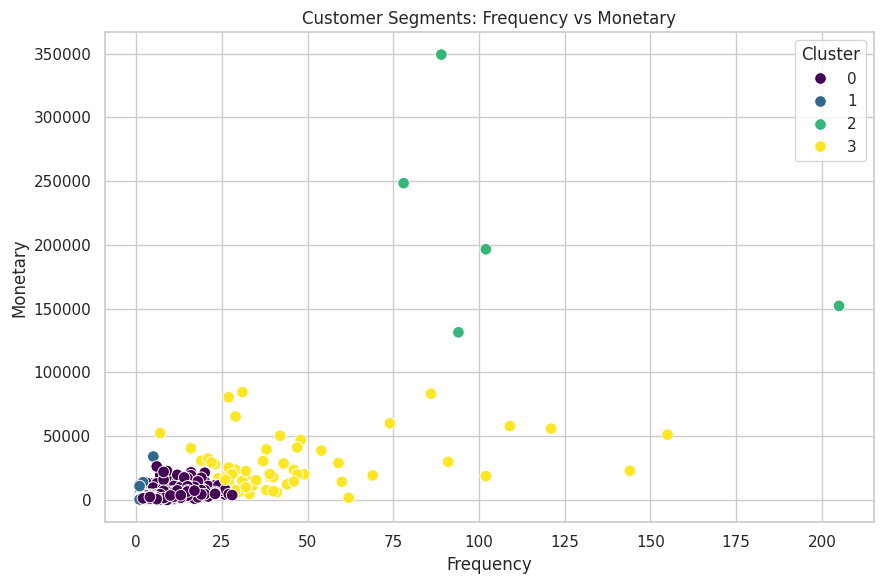

In [36]:
# Frequency vs Monetary
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=70
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')

plt.tight_layout()
plt.show()

# Profile Each Cluster
This is one of the most important parts.

In [37]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.07,4.43,1710.80
1,242.98,1.66,596.88
2,5.60,113.60,215543.67
3,14.27,46.03,28018.43


In [38]:
# Count customers
cluster_size = rfm['Cluster'].value_counts().sort_index()

cluster_size

,count
Cluster,
0,3201
1,1047
2,5
3,59


In [39]:
# Combine them
cluster_profile['Customer_Count'] = cluster_size

cluster_profile

,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,43.07,4.43,1710.80,3201
1,242.98,1.66,596.88,1047
2,5.60,113.60,215543.67,5
3,14.27,46.03,28018.43,59


# Customer Count Bar Chart

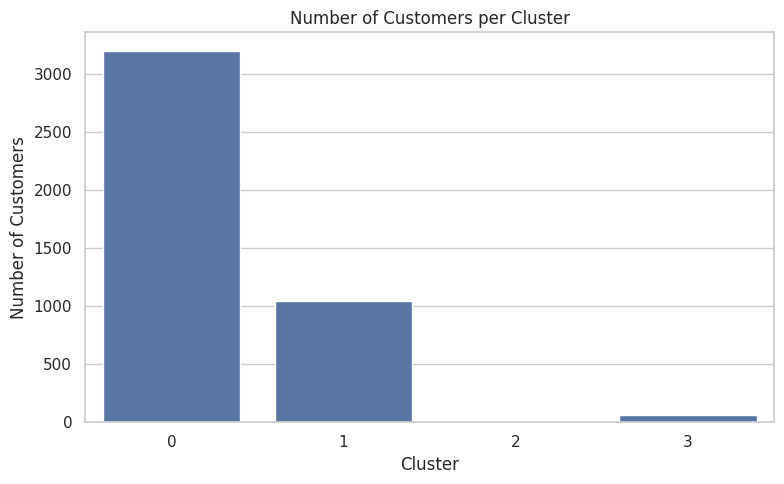

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_size.index,
    y=cluster_size.values
)

plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [41]:
rfm_temp = rfm.reset_index()
cluster_profile = rfm_temp.groupby('Cluster').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median'],
    'Customer ID': 'count'
})

cluster_profile.round(2)

Recency        Frequency          Monetary            Customer ID
           mean median      mean median       mean     median       count
Cluster                                                                  
0         43.07   33.0      4.43    3.0    1710.80     924.52        3201
1        242.98  233.0      1.66    1.0     596.88     306.58        1047
2          5.60    7.0    113.60   94.0  215543.67  196566.74           5
3         14.27    4.0     46.03   38.0   28018.43   20329.68          59

In [42]:
print(rfm['Cluster'].value_counts().sort_index())

Cluster
0    3201
1    1047
2       5
3      59
Name: count, dtype: int64


In [43]:
# RFM distributions
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2048.238236
std,96.860633,8.170213,8914.481280
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.987500
50%,53.000000,2.000000,706.020000
75%,136.000000,5.000000,1723.142500
max,374.000000,205.000000,349164.350000


In [44]:
rfm[['Recency', 'Frequency', 'Monetary']].skew()

,0
Recency,1.282928
Frequency,10.546821
Monetary,23.978464


# Observations and Cluster Interpretation

The RFM analysis identified four distinct customer segments using K-Means clustering.

### Cluster 0 – Regular Customers
- Customer count: 3,201
- Average Recency: 43.07 days
- Average Frequency: 4.43 purchases
- Average Monetary Value: 1,710.80

This is the largest customer segment. These customers show moderate purchasing frequency and spending and represent the core regular customer base.

### Cluster 1 – At-Risk / Inactive Customers
- Customer count: 1,047
- Average Recency: 242.98 days
- Average Frequency: 1.66 purchases
- Average Monetary Value: 596.88

These customers have not purchased recently and have relatively low purchase frequency and monetary value. They may require re-engagement campaigns or targeted offers.

### Cluster 2 – High-Value Customers
- Customer count: 5
- Average Recency: 5.60 days
- Average Frequency: 113.60 purchases
- Average Monetary Value: 215,543.67

This is a very small but extremely valuable customer segment. These customers purchase very frequently and generate exceptionally high monetary value.

### Cluster 3 – Loyal High-Value Customers
- Customer count: 59
- Average Recency: 14.27 days
- Average Frequency: 46.03 purchases
- Average Monetary Value: 28,018.43

These customers purchase frequently, purchased recently, and generate substantially higher monetary value than the majority of customers. They represent an important loyal customer segment.

### Overall Observations

- The majority of customers belong to Cluster 0, representing the regular customer base.
- Cluster 1 contains a large group of relatively inactive or at-risk customers.
- Clusters 2 and 3 contain a small number of highly valuable customers.
- The RFM distributions are highly right-skewed, particularly Frequency and Monetary Value, indicating that a small number of customers contribute disproportionately high purchasing activity and revenue.

# Conclusion

This customer segmentation analysis used RFM (Recency, Frequency, and Monetary) analysis and K-Means clustering to identify groups of customers with different purchasing behaviours.

The analysis identified four customer segments: regular customers, at-risk/inactive customers, high-value customers, and loyal high-value customers. The majority of customers belonged to the regular customer segment, while a small number of customers generated exceptionally high purchase frequency and monetary value.

These segments can help businesses develop targeted strategies such as re-engagement campaigns for inactive customers, loyalty programs for regular customers, and personalized rewards or retention strategies for high-value customers.

Overall, RFM analysis combined with K-Means clustering provides a useful data-driven approach for understanding customer behaviour and supporting targeted marketing and customer relationship management decisions.